In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# =========================
# 1. Load data
# =========================
df = pd.read_csv("../../data/features_df.csv")

# Drop user_id if it exists
X = df.drop(columns=["user_id"], errors="ignore")

# Convert boolean columns to int
bool_cols = X.select_dtypes(include=["bool"]).columns
for col in bool_cols:
    X[col] = X[col].astype(int)

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Fill missing values if any
X = X.fillna(0)

/var/folders/jh/9_qy7nd96v9_q0_x1sffyq9c0000gn/T/ipykernel_58578/1829113387.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


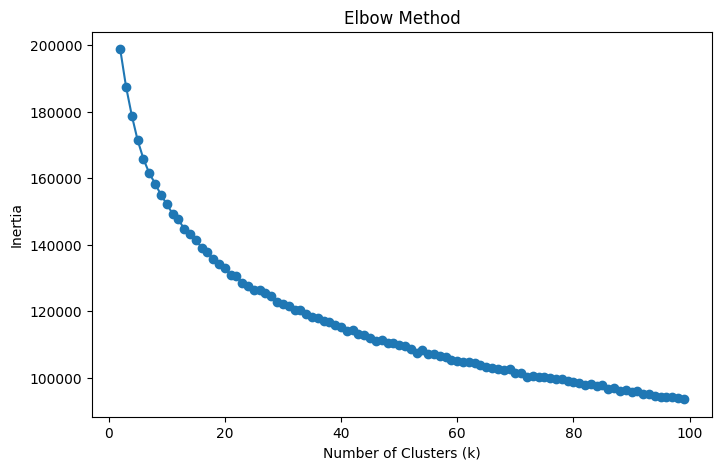

In [6]:
# =========================
# 2. Scale features
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================
# 3. Elbow Method
# =========================
k_range = range(2, 100)
inertia_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

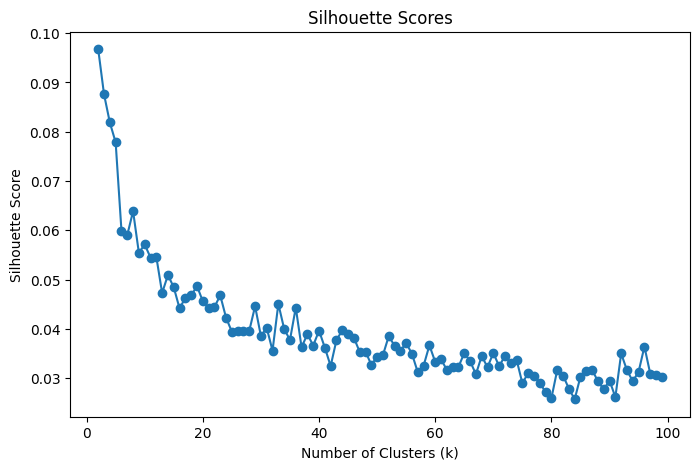

k = 2, silhouette score = 0.0968
k = 3, silhouette score = 0.0876
k = 4, silhouette score = 0.0819
k = 5, silhouette score = 0.0779
k = 6, silhouette score = 0.0599
k = 7, silhouette score = 0.0590
k = 8, silhouette score = 0.0639
k = 9, silhouette score = 0.0554
k = 10, silhouette score = 0.0571
k = 11, silhouette score = 0.0545
k = 12, silhouette score = 0.0546
k = 13, silhouette score = 0.0473
k = 14, silhouette score = 0.0509
k = 15, silhouette score = 0.0484
k = 16, silhouette score = 0.0441
k = 17, silhouette score = 0.0463
k = 18, silhouette score = 0.0468
k = 19, silhouette score = 0.0487
k = 20, silhouette score = 0.0456
k = 21, silhouette score = 0.0443
k = 22, silhouette score = 0.0444
k = 23, silhouette score = 0.0468
k = 24, silhouette score = 0.0423
k = 25, silhouette score = 0.0394
k = 26, silhouette score = 0.0396
k = 27, silhouette score = 0.0396
k = 28, silhouette score = 0.0396
k = 29, silhouette score = 0.0446
k = 30, silhouette score = 0.0385
k = 31, silhouette sco

In [7]:
# =========================
# 4. Silhouette Scores
# =========================
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

for k, score in zip(k_range, silhouette_scores):
    print(f"k = {k}, silhouette score = {score:.4f}")

In [10]:
# =========================
# 5. Final K-means
# =========================
best_k = 15

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels


# =========================
# 6. Cluster sizes
# =========================
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())


Cluster counts:
cluster
0     132
1      50
2      76
3      53
4     243
5     216
6     112
7     256
8       5
9     219
10    168
11    129
12     95
13      2
14    176
Name: count, dtype: int64


In [11]:
# =========================
# 7. Cluster profile
# =========================
X_with_cluster = X.copy()
X_with_cluster["cluster"] = cluster_labels

cluster_profile = X_with_cluster.groupby("cluster").mean()
print("\nCluster profile:")
print(cluster_profile)

cluster_profile_std = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()


# =========================
# 8. Top features per cluster
# =========================
for c in cluster_profile.index:
    print(f"\nCluster {c} - Top features:")
    print(cluster_profile.loc[c].sort_values(ascending=False).head(10))


Cluster profile:
         temporal_peak_hour  temporal_night_ratio  temporal_h_dist_0  \
cluster                                                                
0                  9.371212              0.234647           0.028945   
1                 15.040000              0.210493           0.045711   
2                 14.815789              0.127857           0.031074   
3                 13.566038              0.157129           0.037838   
4                 11.588477              0.342386           0.067472   
5                 15.194444              0.062810           0.018560   
6                 12.357143              0.283745           0.053083   
7                 15.710938              0.068999           0.020510   
8                 11.200000              0.176206           0.032507   
9                 17.634703              0.065144           0.021109   
10                17.869048              0.098066           0.030238   
11                15.209302              0.070

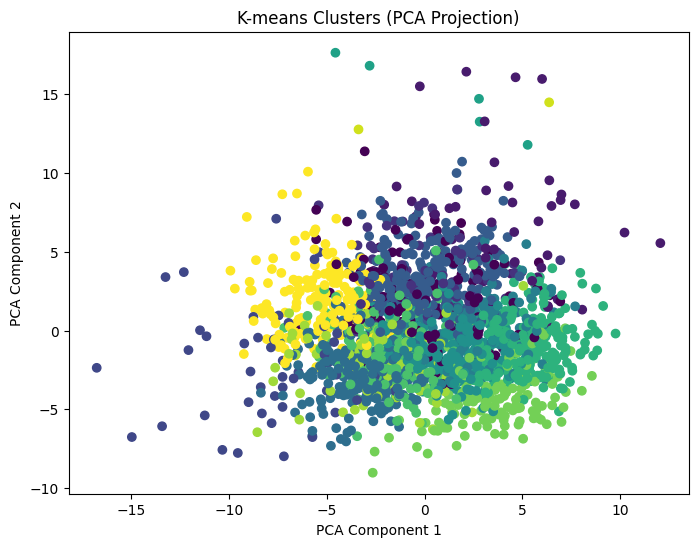

In [12]:
# =========================
# 9. PCA visualization
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters (PCA Projection)")
plt.show()

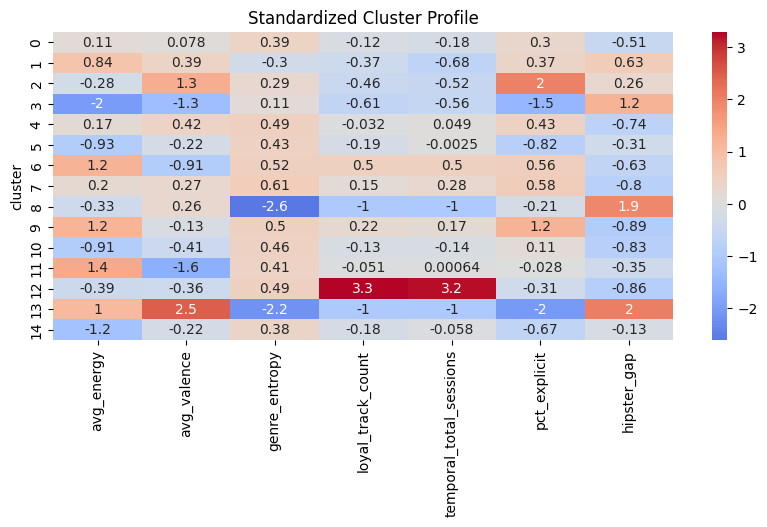

In [13]:
# =========================
# 10. Selected-feature heatmap
# =========================
important_features = [
    "avg_energy",
    "avg_valence",
    "genre_entropy",
    "loyal_track_count",
    "temporal_total_sessions",
    "pct_explicit",
    "hipster_gap",
]

available_features = [f for f in important_features if f in cluster_profile_std.columns]

plt.figure(figsize=(10, 4))
sns.heatmap(
    cluster_profile_std[available_features], cmap="coolwarm", center=0, annot=True
)
plt.title("Standardized Cluster Profile")
plt.show()


# =========================
# 11. Save results
# =========================
df.to_csv("../../data/features_with_clusters.csv", index=False)
cluster_profile.to_csv("../../data/cluster_profile.csv")
cluster_profile_std.to_csv("../../data/cluster_profile_standardized.csv")